In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('data/DoktorAvalanche_with_features_engineered.csv')

In [4]:
df.head()

,game_id,move_number,increment_sec,time_left_sec,time_spent_sec,time_left_ratio,eval,mate,eval_volatility,pieces_remaining,...,eval_unified,complexity_material_norm,eval_volatility_norm,time_pressure_norm,material_time_pressure_int,time_eval_volatility_int,move_number_norm,late_endgame_int,cumulative_time_pressure,color_white
0,01k2vd00,1,3,300.03,0.00,1.000100,25.0,NaN,NaN,32,...,25.0,1.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,1
1,01k2vd00,2,3,301.15,1.88,1.003833,79.0,NaN,NaN,32,...,79.0,1.000000,0.000000,0.0,0.0,0.0,0.142857,0.0,0.411507,1
2,01k2vd00,3,3,302.59,1.56,1.008633,71.0,NaN,23.795424,32,...,71.0,1.000000,0.048465,0.0,0.0,0.0,0.285714,0.0,0.501980,1
3,01k2vd00,4,3,303.71,1.88,1.012367,249.0,NaN,82.089382,31,...,249.0,0.987179,0.167194,0.0,0.0,0.0,0.428571,0.0,0.582239,1
4,01k2vd00,5,3,304.67,2.04,1.015567,371.0,NaN,123.183693,30,...,371.0,0.948718,0.250892,0.0,0.0,0.0,0.571429,0.0,0.644403,1


In [5]:
df.columns

Index(['game_id', 'move_number', 'increment_sec', 'time_left_sec',
       'time_spent_sec', 'time_left_ratio', 'eval', 'mate', 'eval_volatility',
       'pieces_remaining', 'material_density', 'num_minor_pieces', 'num_rooks',
       'num_queens', 'num_pawns', 'complexity_material_score',
       'white_castled_king', 'white_castled_queen', 'black_castled_king',
       'black_castled_queen', 'queen_present', 'is_opening', 'is_middlegame',
       'is_endgame', 'is_pawn_move', 'is_knight_move', 'is_bishop_move',
       'is_rook_move', 'is_queen_move', 'is_king_move',
       'avg_time_spent_per_move', 'time_spent_ratio', 'is_mate_threat',
       'is_checkmate', 'is_inaccuracy', 'is_mistake', 'is_blunder',
       'eval_unified', 'complexity_material_norm', 'eval_volatility_norm',
       'time_pressure_norm', 'material_time_pressure_int',
       'time_eval_volatility_int', 'move_number_norm', 'late_endgame_int',
       'cumulative_time_pressure', 'color_white'],
      dtype='str')

In [6]:
# Drop unneeded columns and columns created during hypothesis testing
df = df.drop(['game_id', 'eval', 'mate' ], axis = 1)

In [7]:
df.dtypes

move_number                     int64
increment_sec                   int64
time_left_sec                 float64
time_spent_sec                float64
time_left_ratio               float64
eval_volatility               float64
pieces_remaining                int64
material_density              float64
num_minor_pieces                int64
num_rooks                       int64
num_queens                      int64
num_pawns                       int64
complexity_material_score       int64
white_castled_king              int64
white_castled_queen             int64
black_castled_king              int64
black_castled_queen             int64
queen_present                   int64
is_opening                      int64
is_middlegame                   int64
is_endgame                      int64
is_pawn_move                    int64
is_knight_move                  int64
is_bishop_move                  int64
is_rook_move                    int64
is_queen_move                   int64
is_king_move

In [8]:
[col for col in df.columns if df[col].dtype == 'str']

[]

In [9]:
df.isnull().sum()

move_number                      0
increment_sec                    0
time_left_sec                    0
time_spent_sec                   0
time_left_ratio                  0
eval_volatility               1698
pieces_remaining                 0
material_density                 0
num_minor_pieces                 0
num_rooks                        0
num_queens                       0
num_pawns                        0
complexity_material_score        0
white_castled_king               0
white_castled_queen              0
black_castled_king               0
black_castled_queen              0
queen_present                    0
is_opening                       0
is_middlegame                    0
is_endgame                       0
is_pawn_move                     0
is_knight_move                   0
is_bishop_move                   0
is_rook_move                     0
is_queen_move                    0
is_king_move                     0
avg_time_spent_per_move          0
time_spent_ratio    

In [10]:
# Can drop the eval_volatility rows since NA for the first 2 moves and are negligible
df.dropna(inplace=True)

In [11]:
df.isnull().sum()

move_number                   0
increment_sec                 0
time_left_sec                 0
time_spent_sec                0
time_left_ratio               0
eval_volatility               0
pieces_remaining              0
material_density              0
num_minor_pieces              0
num_rooks                     0
num_queens                    0
num_pawns                     0
complexity_material_score     0
white_castled_king            0
white_castled_queen           0
black_castled_king            0
black_castled_queen           0
queen_present                 0
is_opening                    0
is_middlegame                 0
is_endgame                    0
is_pawn_move                  0
is_knight_move                0
is_bishop_move                0
is_rook_move                  0
is_queen_move                 0
is_king_move                  0
avg_time_spent_per_move       0
time_spent_ratio              0
is_mate_threat                0
is_checkmate                  0
is_inacc

In [12]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.nunique()

move_number                      89
increment_sec                     5
time_left_sec                  4607
time_spent_sec                 1567
time_left_ratio                6641
eval_volatility               11434
pieces_remaining                 31
material_density                 31
num_minor_pieces                  9
num_rooks                         5
num_queens                        5
num_pawns                        17
complexity_material_score        76
white_castled_king                2
white_castled_queen               2
black_castled_king                2
black_castled_queen               2
queen_present                     2
is_opening                        2
is_middlegame                     2
is_endgame                        2
is_pawn_move                      2
is_knight_move                    2
is_bishop_move                    2
is_rook_move                      2
is_queen_move                     2
is_king_move                      2
avg_time_spent_per_move     

In [15]:
from IPython.display import display
pd.options.display.max_columns = None

In [16]:
df.describe()

,move_number,increment_sec,time_left_sec,time_spent_sec,time_left_ratio,eval_volatility,pieces_remaining,material_density,num_minor_pieces,num_rooks,num_queens,num_pawns,complexity_material_score,white_castled_king,white_castled_queen,black_castled_king,black_castled_queen,queen_present,is_opening,is_middlegame,is_endgame,is_pawn_move,is_knight_move,is_bishop_move,is_rook_move,is_queen_move,is_king_move,avg_time_spent_per_move,time_spent_ratio,is_mate_threat,is_checkmate,is_inaccuracy,is_mistake,is_blunder,eval_unified,complexity_material_norm,eval_volatility_norm,time_pressure_norm,material_time_pressure_int,time_eval_volatility_int,move_number_norm,late_endgame_int,cumulative_time_pressure,color_white
count,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000
mean,21.290357,2.684646,181.906536,7.896348,0.644099,314.544981,22.530337,0.704073,4.670176,2.988363,0.936837,12.605214,49.989090,0.560808,0.119933,0.474295,0.150059,0.613138,0.172874,0.371473,0.455652,0.245033,0.169085,0.166482,0.158213,0.148452,0.112736,7.546976,1.036997,0.044482,0.005666,0.050262,0.018987,0.031620,112.281512,0.640886,0.168240,0.358269,0.169309,0.082088,0.515022,0.313103,0.861346,0.509819
std,14.240594,0.838915,94.208100,8.998178,0.312814,1277.692220,7.259970,0.226874,2.562713,1.443822,0.842369,2.745569,20.736622,0.496298,0.324889,0.499348,0.357136,0.487041,0.378146,0.483208,0.498039,0.430115,0.374834,0.372520,0.364948,0.355554,0.316276,2.372942,1.064055,0.206167,0.075057,0.218490,0.136482,0.174989,3819.298646,0.265854,0.245015,0.309812,0.144840,0.167006,0.271381,0.368878,0.373105,0.499913
min,3.000000,0.000000,0.050000,0.000000,0.000119,0.000000,2.000000,0.062500,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.543333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-16746.400000,0.038462,0.000000,0.000000,0.000000,0.000000,0.021978,0.000000,0.000000,0.000000
25%,10.000000,3.000000,102.750000,2.440000,0.380633,14.406122,18.000000,0.562500,3.000000,2.000000,0.000000,11.000000,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.870741,0.351048,0.000000,0.000000,0.000000,0.000000,0.000000,-130.000000,0.410256,0.029341,0.060967,0.047970,0.001800,0.280000,0.000000,0.595023,0.000000
50%,18.000000,3.000000,182.670000,4.360000,0.707833,34.097898,24.000000,0.750000,5.000000,4.000000,1.000000,13.000000,53.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.336349,0.657895,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000,0.679487,0.069448,0.292167,0.144162,0.017864,0.516129,0.000000,0.962677,1.000000
75%,29.000000,3.000000,272.590000,9.800000,0.939033,88.060585,29.000000,0.906250,7.000000,4.000000,2.000000,15.000000,68.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.107143,1.343656,0.000000,0.000000,0.000000,0.000000,0.000000,237.000000,0.871795,0.179356,0.619367,0.255503,0.070653,0.750000,0.685185,1.086855,1.000000
max,91.000000,5.000000,417.950000,106.510000,1.463583,8599.817689,32.000000,1.000000,8.000000,4.000000,4.000000,16.000000,78.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000

In [18]:
binary_columns = [
    col for col in df.columns
    if df[col].nunique() == 2 and col not in ['is_inaccuracy', 'is_mistake', 'is_blunder']
]
binary_columns

['white_castled_king',
 'white_castled_queen',
 'black_castled_king',
 'black_castled_queen',
 'queen_present',
 'is_opening',
 'is_middlegame',
 'is_endgame',
 'is_pawn_move',
 'is_knight_move',
 'is_bishop_move',
 'is_rook_move',
 'is_queen_move',
 'is_king_move',
 'is_mate_threat',
 'is_checkmate',
 'color_white']

In [19]:
def plot_binary_feature_analysis(df, binary_features, target=''):
    n_features = len(binary_features)
    n_cols = 3
    n_rows = 20
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 25))
    axes = axes.flatten()
    
    for idx, feature in enumerate(binary_features):
        ax = axes[idx]
        
        # Calculate counts and percentages
        crosstab = pd.crosstab(df[feature], df[target])
        crosstab_pct = pd.crosstab(df[feature], df[target], normalize='index') * 100
        
        # Plot grouped bars
        x = np.arange(2)
        width = 0.35
        
        ax.bar(x - width/2, crosstab[0], width, label= f'No {target}', color='skyblue')
        ax.bar(x + width/2, crosstab[1], width, label= f'{target}', color='coral')
        
        # Add percentage labels
        for i, (no_pct, yes_pct) in enumerate(zip(crosstab_pct[0], crosstab_pct[1])):
            ax.text(i - width/2, crosstab.iloc[i, 0], f'{no_pct:.1f}%', 
                    ha='center', va='bottom', fontsize=9)
            ax.text(i + width/2, crosstab.iloc[i, 1], f'{yes_pct:.1f}%', 
                    ha='center', va='bottom', fontsize=9)
        
        ax.set_xlabel(f'{feature}')
        ax.set_ylabel('Count')
        ax.set_title(f'{feature} vs {target}')
        ax.set_xticks(x)
        ax.set_xticklabels(['No', 'Yes'])
        ax.legend()
    
    # Hide empty subplots if there are any
    for idx in range(n_features, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

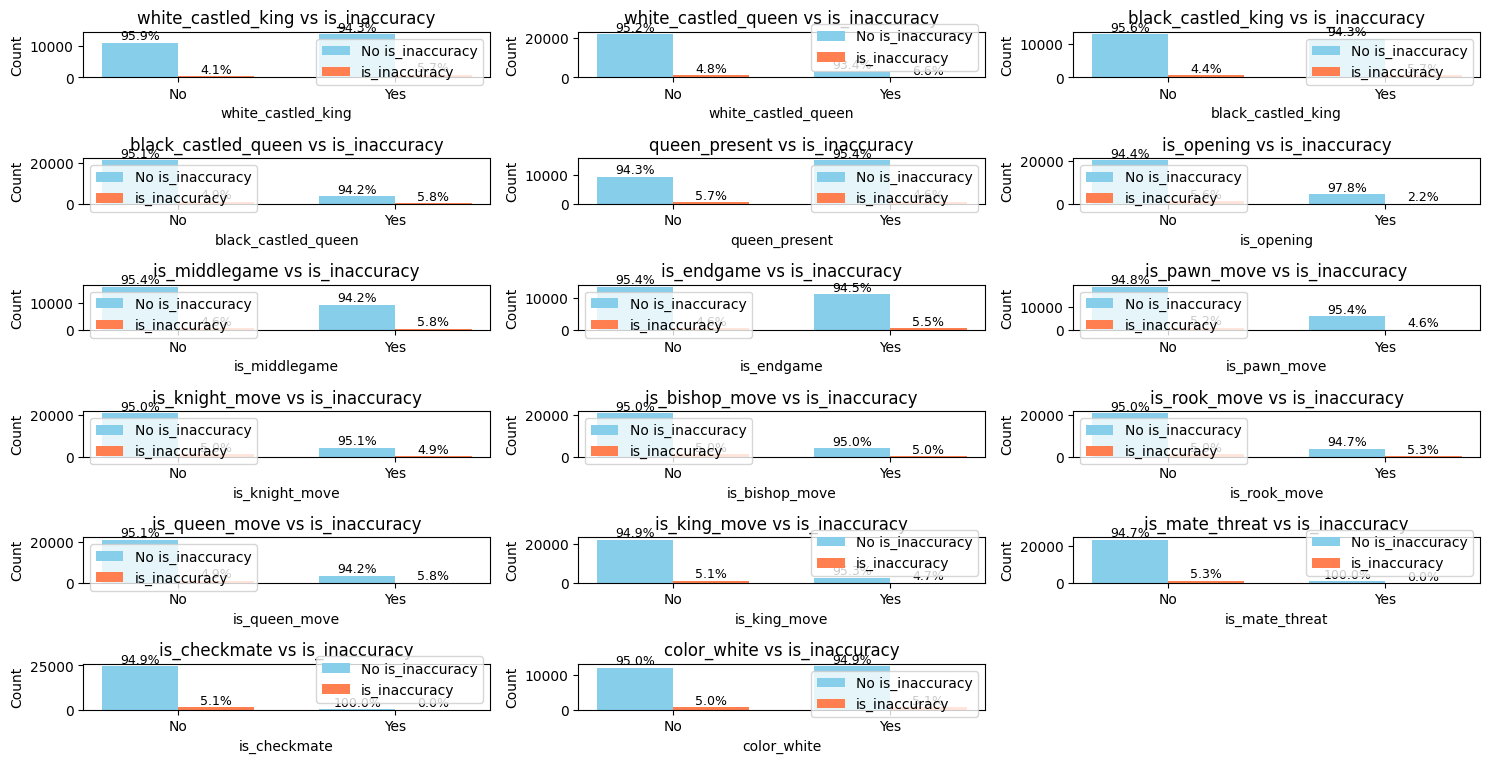

In [20]:
plot_binary_feature_analysis(df, binary_columns, target='is_inaccuracy')

Observations
* For inaccuracies, it looks like:
* King Moves - about 4.7% of king moves is inaccuracy
* Queen moves - about 6% of queen moves is inaccuracy
* rook moves - 5.3% for rook
* bishop move - 5% of move
* knight moves - 5% of move
* pawn moves - 4.6% for pawn

* Inaccuracies for blitz are higher than for slower games
* It is interesting to see the more powerful pieces (queen and rook) have higher inaccuracy rates Compared to king and minor pieces which are less powerful

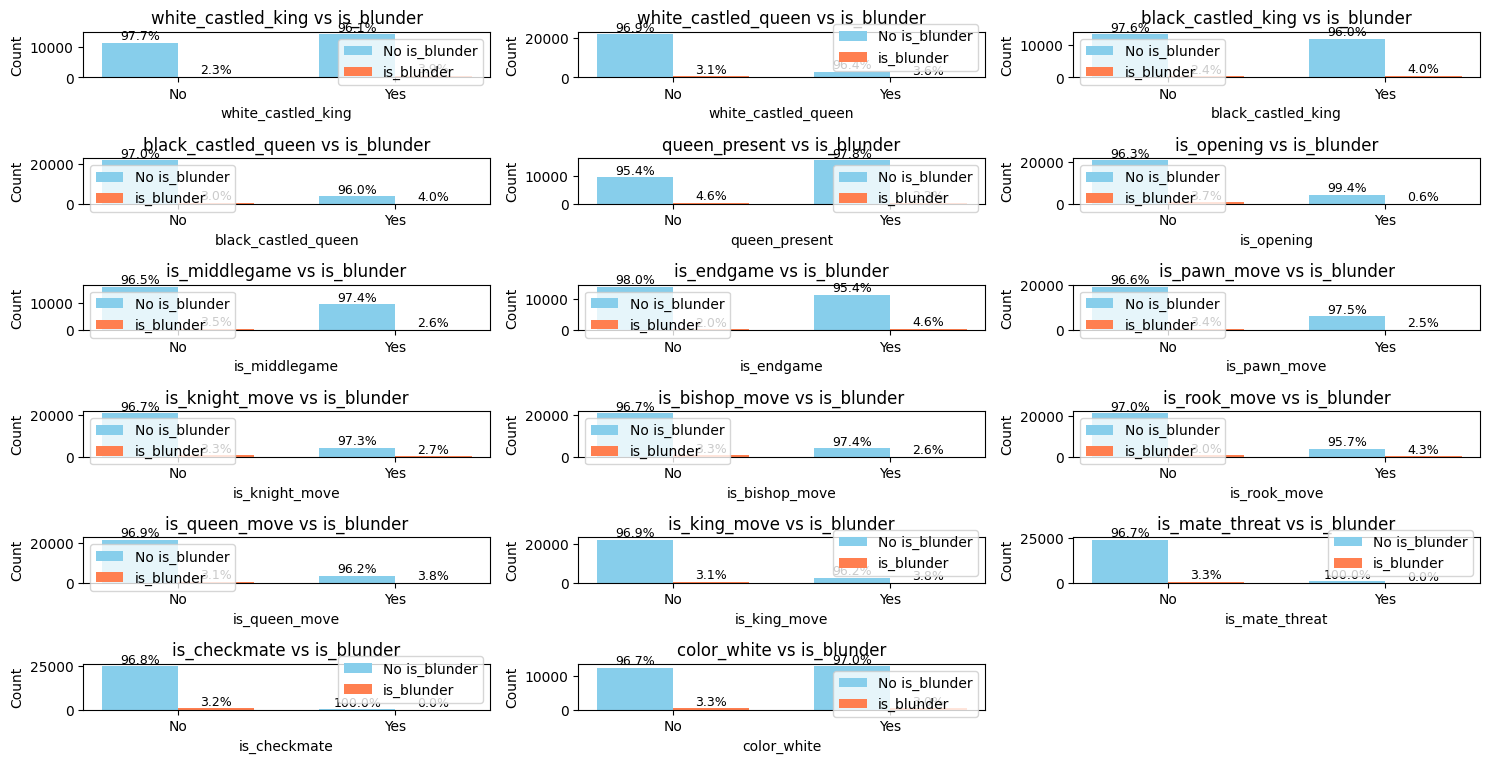

In [22]:
plot_binary_feature_analysis(df, binary_columns, target='is_blunder')

Observations
* For blunders, it looks like
* King Moves - about 3.8% of king moves 
* Queen moves - about 3.8% of queen moves 
* rook moves - 4.3% for rook
* bishop move - 2.6% of move
* knight moves - 2.7% of move
* pawn moves - 2.5% for pawn

* rates are higher for blitz than slower time controls
* It is interesting to see the more powerful pieces (queen and rook) have higher inaccuracy rates Compared to king and minor pieces which are less powerful

In [24]:
is_inaccuracy_percentages = df.groupby('is_inaccuracy')[binary_columns].agg('mean') * 100
is_inaccuracy_percentages

,white_castled_king,white_castled_queen,black_castled_king,black_castled_queen,queen_present,is_opening,is_middlegame,is_endgame,is_pawn_move,is_knight_move,is_bishop_move,is_rook_move,is_queen_move,is_king_move,is_mate_threat,is_checkmate,color_white
is_inaccuracy,,,,,,,,,,,,,,,,,
0,55.671100,11.793632,47.106006,14.877066,61.600161,17.803305,36.860137,45.336558,24.607013,16.928658,16.654575,15.771866,14.723902,11.313986,4.683595,0.596534,50.943168
1,63.823305,15.765423,53.541508,17.440975,55.902513,7.539985,42.574257,49.885758,22.543793,16.527037,16.527037,16.755522,17.136329,10.510282,0.000000,0.000000,51.713633


In [25]:
is_blunder_percentages = df.groupby('is_blunder')[binary_columns].agg('mean') * 100
is_blunder_percentages

,white_castled_king,white_castled_queen,black_castled_king,black_castled_queen,queen_present,is_opening,is_middlegame,is_endgame,is_pawn_move,is_knight_move,is_bishop_move,is_rook_move,is_queen_move,is_king_move,is_mate_threat,is_checkmate,color_white
is_blunder,,,,,,,,,,,,,,,,,
0,55.678539,11.934221,47.001621,14.875282,61.900621,17.745187,37.356208,44.898605,24.678816,16.986204,16.745069,15.638218,14.752737,11.198956,4.59343,0.58505,51.045579
1,68.401937,13.801453,60.532688,19.007264,43.341404,3.268765,30.750605,65.980630,19.128329,14.527845,13.680387,21.428571,17.675545,13.559322,0.00000,0.00000,49.031477


In [26]:
# Numeric columns
numeric_columns = [
    col for col in df.columns
    if df[col].nunique() != 2 and col not in ['is_inaccuracy', 'is_mistake', 'is_blunder']
]
numeric_columns

['move_number',
 'increment_sec',
 'time_left_sec',
 'time_spent_sec',
 'time_left_ratio',
 'eval_volatility',
 'pieces_remaining',
 'material_density',
 'num_minor_pieces',
 'num_rooks',
 'num_queens',
 'num_pawns',
 'complexity_material_score',
 'avg_time_spent_per_move',
 'time_spent_ratio',
 'eval_unified',
 'complexity_material_norm',
 'eval_volatility_norm',
 'time_pressure_norm',
 'material_time_pressure_int',
 'time_eval_volatility_int',
 'move_number_norm',
 'late_endgame_int',
 'cumulative_time_pressure']

In [27]:
def plot_numeric_features_histogram(df, numeric_features, target='', bins=10):
    n_features = len(numeric_features)
    n_cols = 3
    n_rows = 10
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 15))
    axes = axes.flatten()
    
    for idx, feature in enumerate(numeric_features):
        ax = axes[idx]
        
        # Separate data by diabetes status
        no_diabetes = df[df[target] == 0][feature]
        yes_diabetes = df[df[target] == 1][feature]
        
        # Plot histograms
        ax.hist(no_diabetes, bins=bins, color='skyblue', 
                label= f'No {target}', density=True, histtype='step', linewidth=2.5)
        ax.hist(yes_diabetes, bins=bins, color='coral', 
                label= f'{target}', density=True, histtype='step', linewidth=2.5)
        
        # Styling
        ax.set_xlabel(feature, fontsize=11)
        ax.set_ylabel('Density', fontsize=11)
        ax.set_title(f'Distribution of {feature} by {target}', fontsize=12, fontweight='bold')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3, axis='y')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    # Hide empty subplots
    for idx in range(n_features, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

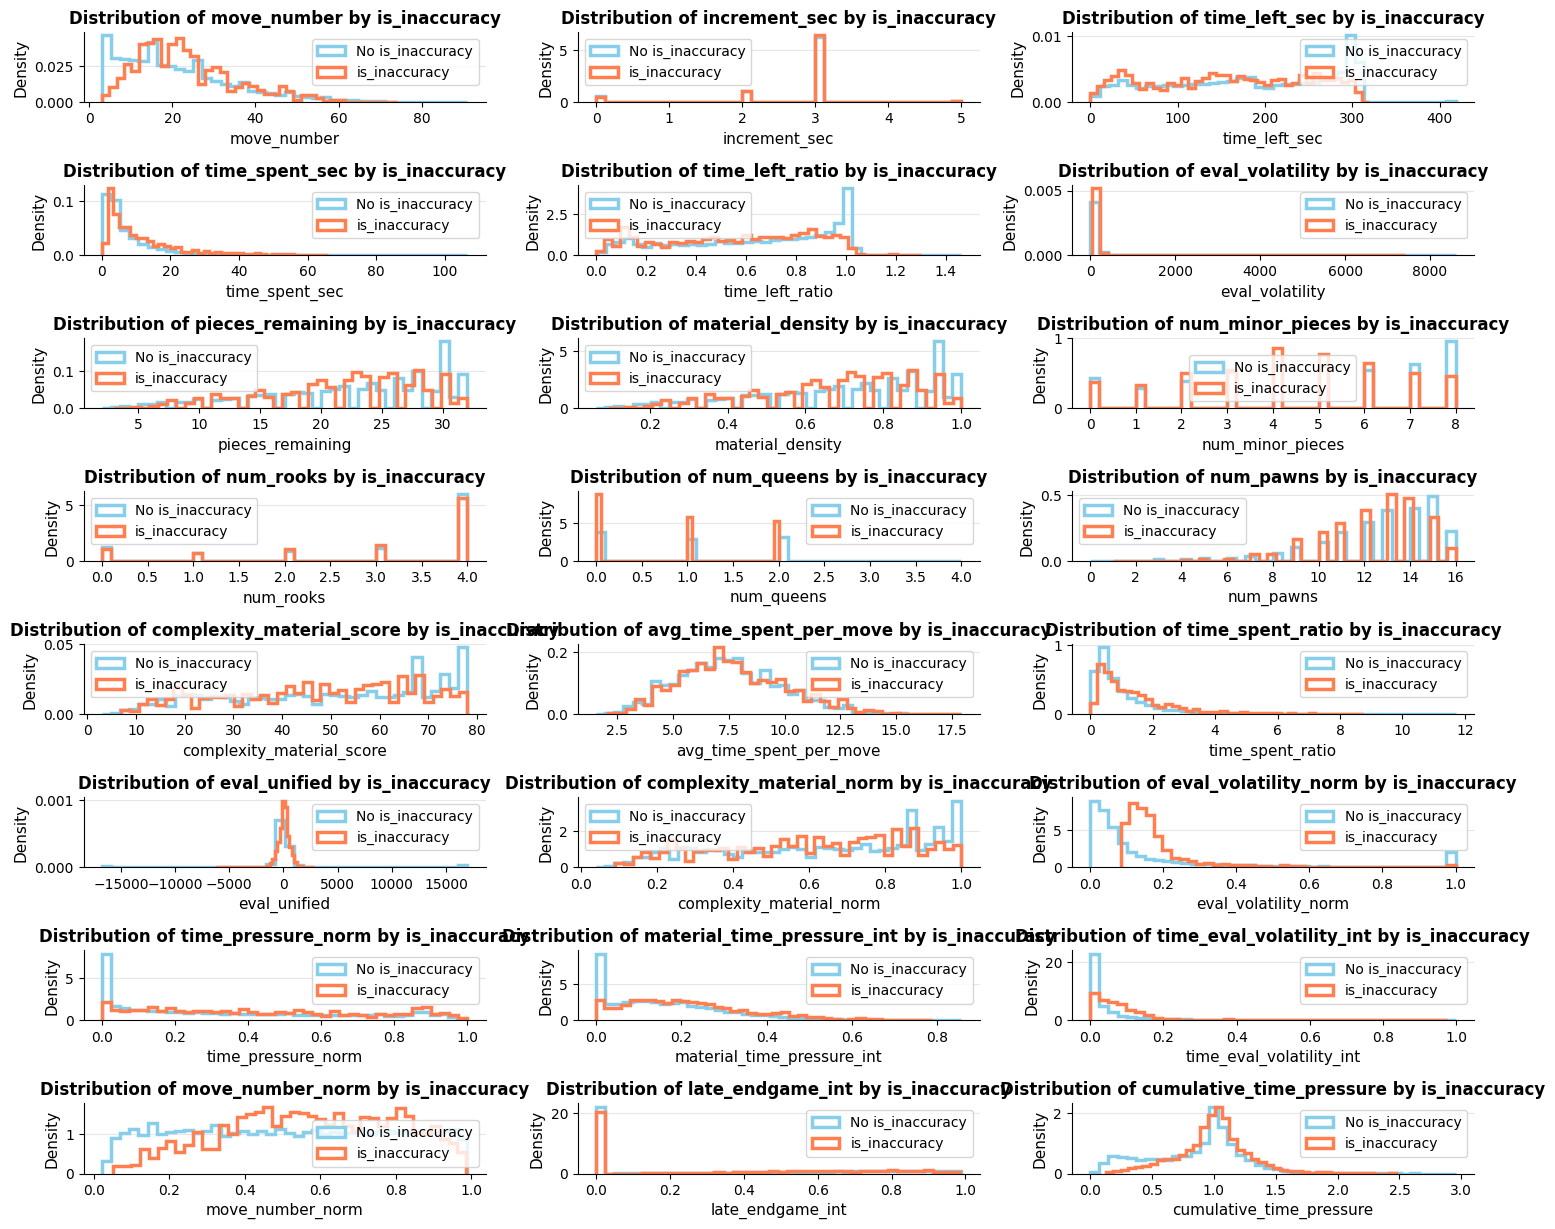

In [28]:
plot_numeric_features_histogram(df, numeric_columns, target='is_inaccuracy', bins=40)

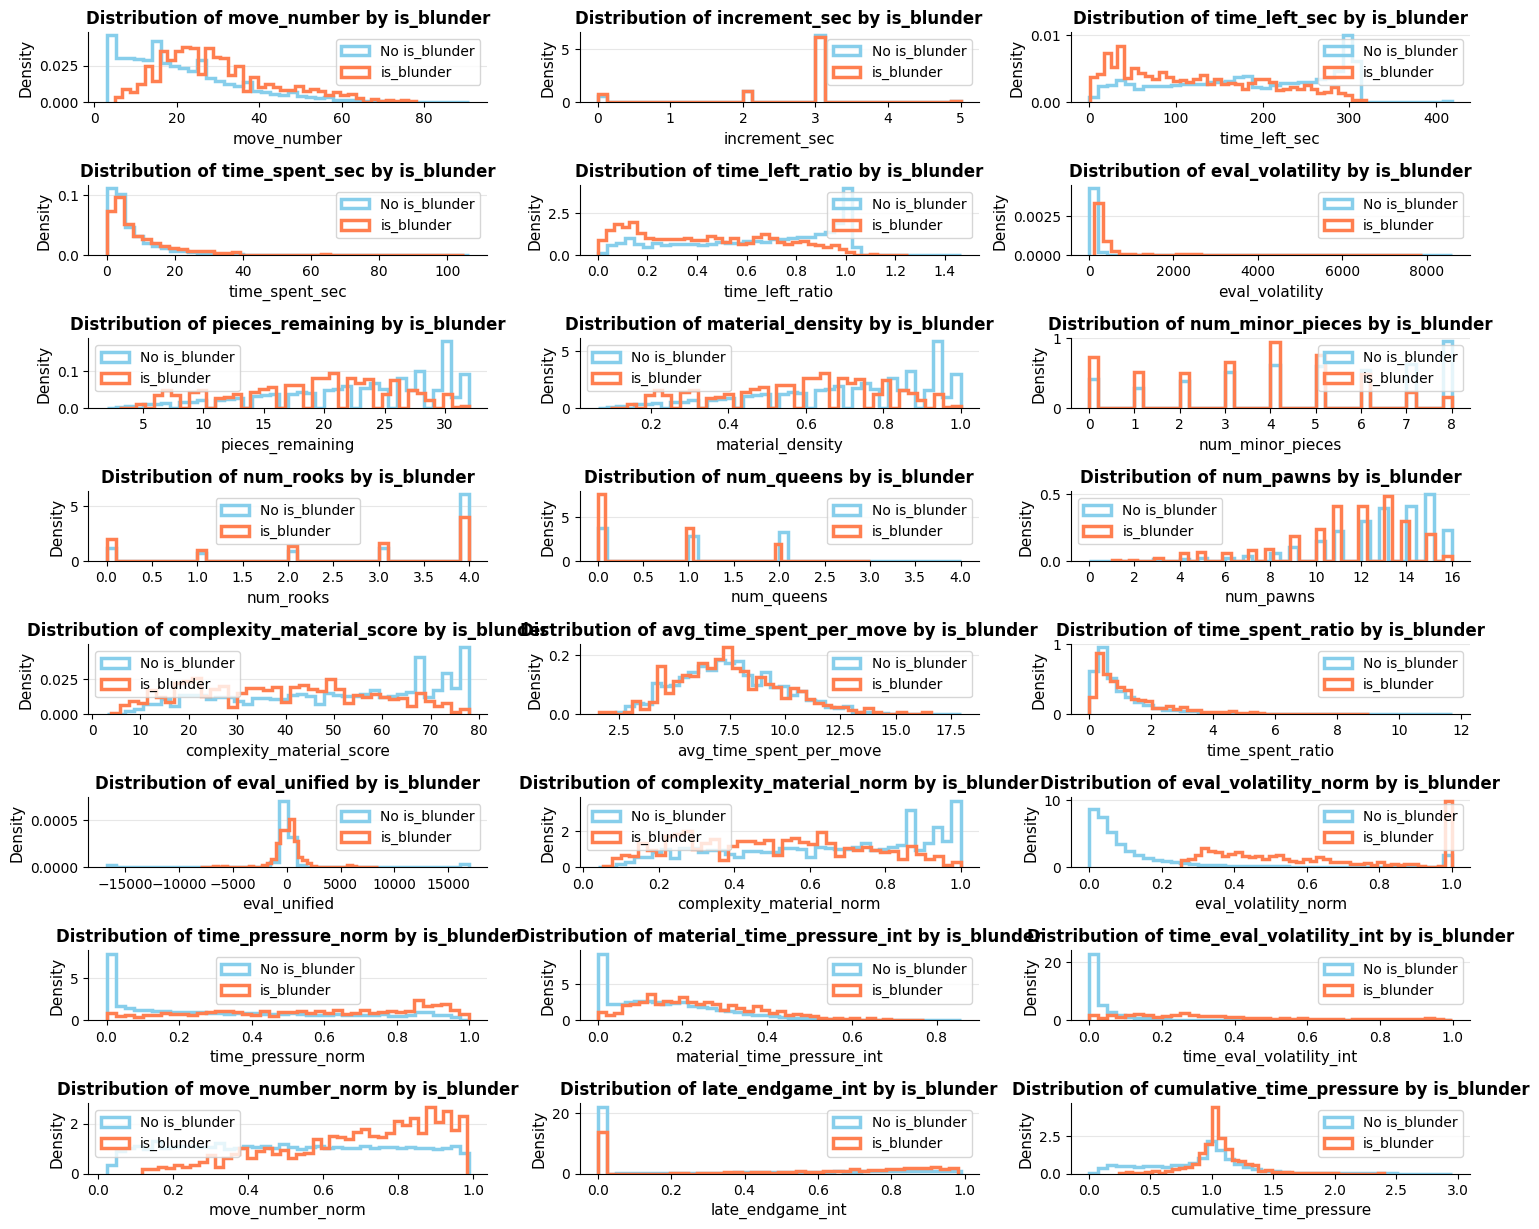

In [29]:
plot_numeric_features_histogram(df, numeric_columns, target='is_blunder', bins=40)

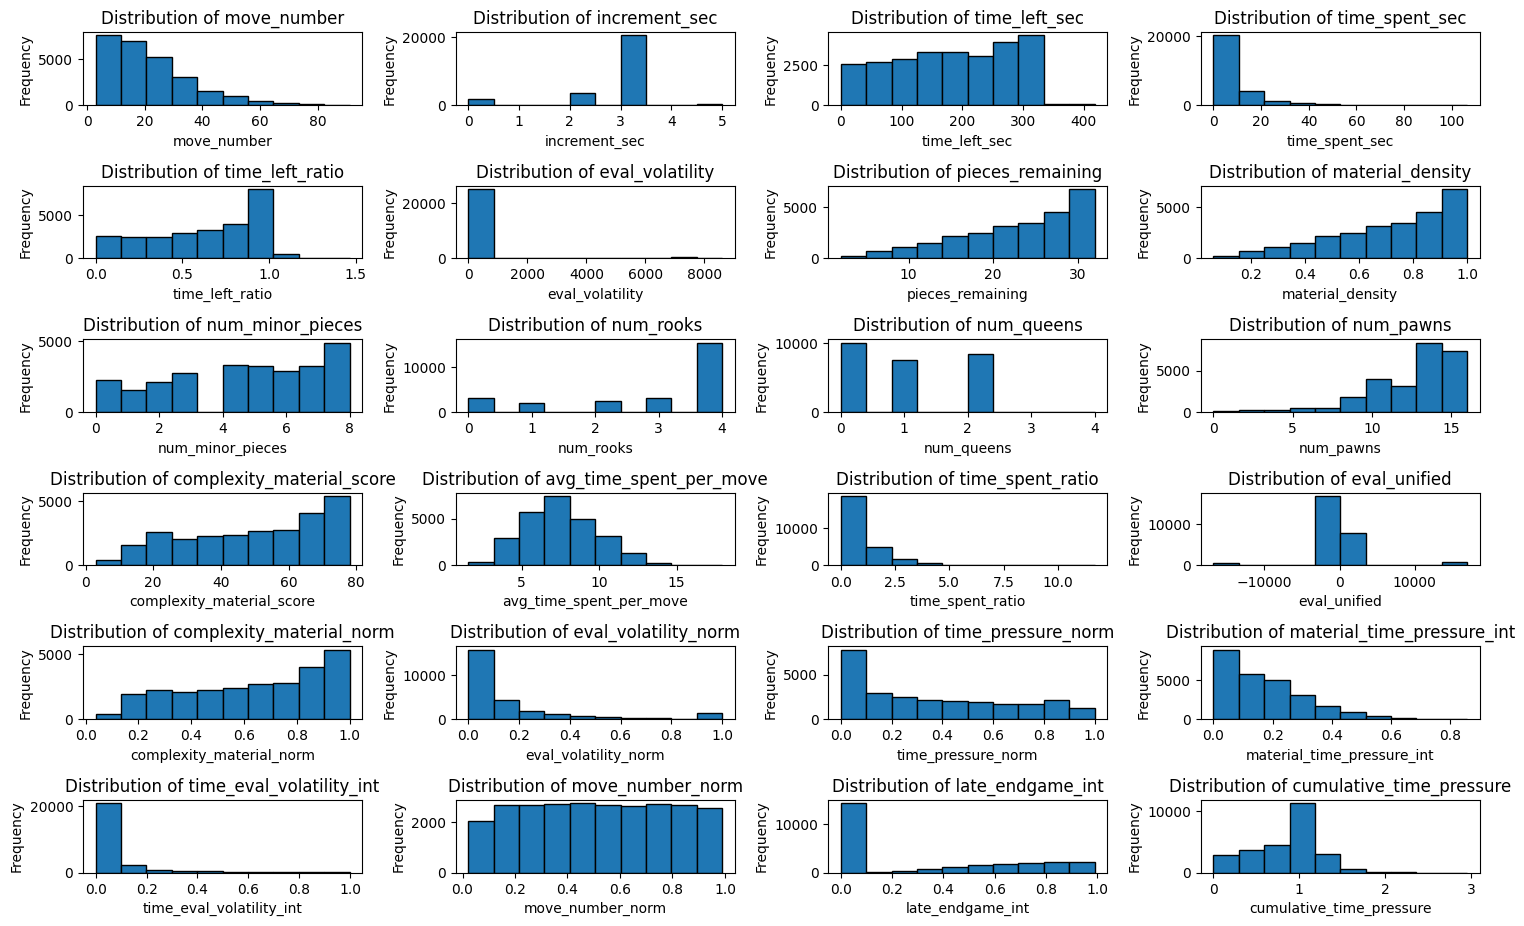

In [30]:
num_cols = len(numeric_columns)
n_cols = 4
n_rows = 8

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    axes[i].hist(df[col], bins=10, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide empty subplots if there are any
for idx in range(num_cols, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [31]:
is_inaccuracy_percentages = df.groupby('is_inaccuracy')[numeric_columns].mean()
is_inaccuracy_percentages

,move_number,increment_sec,time_left_sec,time_spent_sec,time_left_ratio,eval_volatility,pieces_remaining,material_density,num_minor_pieces,num_rooks,num_queens,num_pawns,complexity_material_score,avg_time_spent_per_move,time_spent_ratio,eval_unified,complexity_material_norm,eval_volatility_norm,time_pressure_norm,material_time_pressure_int,time_eval_volatility_int,move_number_norm,late_endgame_int,cumulative_time_pressure
is_inaccuracy,,,,,,,,,,,,,,,,,,,,,,,,
0,21.182426,2.683071,183.151568,7.706527,0.648468,325.417807,22.573881,0.705434,4.690891,2.989359,0.942805,12.623821,50.128537,7.538578,1.013839,117.121844,0.642674,0.167244,0.353972,0.166451,0.081890,0.511914,0.311987,0.854335
1,23.329779,2.714395,158.380853,11.483138,0.561536,109.095772,21.707540,0.678361,4.278751,2.969535,0.824067,12.253618,47.354151,7.705654,1.474593,20.820259,0.607104,0.187064,0.439447,0.223321,0.085817,0.573734,0.334179,0.993825


In [32]:
is_blunder = df.groupby('is_blunder')[numeric_columns].mean()
is_blunder

,move_number,increment_sec,time_left_sec,time_spent_sec,time_left_ratio,eval_volatility,pieces_remaining,material_density,num_minor_pieces,num_rooks,num_queens,num_pawns,complexity_material_score,avg_time_spent_per_move,time_spent_ratio,eval_unified,complexity_material_norm,eval_volatility_norm,time_pressure_norm,material_time_pressure_int,time_eval_volatility_int,move_number_norm,late_endgame_int,cumulative_time_pressure
is_blunder,,,,,,,,,,,,,,,,,,,,,,,,
0,21.013085,2.687157,183.882803,7.808143,0.651023,307.318737,22.658971,0.708093,4.712614,3.005574,0.948413,12.651105,50.352532,7.545513,1.025728,112.156933,0.645545,0.154263,0.351391,0.166758,0.073264,0.509223,0.307118,0.854965
1,29.782082,2.607748,121.381574,10.597688,0.432051,535.855283,18.590799,0.580962,3.370460,2.461259,0.582324,11.199758,38.858354,7.591788,1.382119,116.096852,0.498184,0.596298,0.568896,0.247451,0.352321,0.692609,0.496381,1.056782


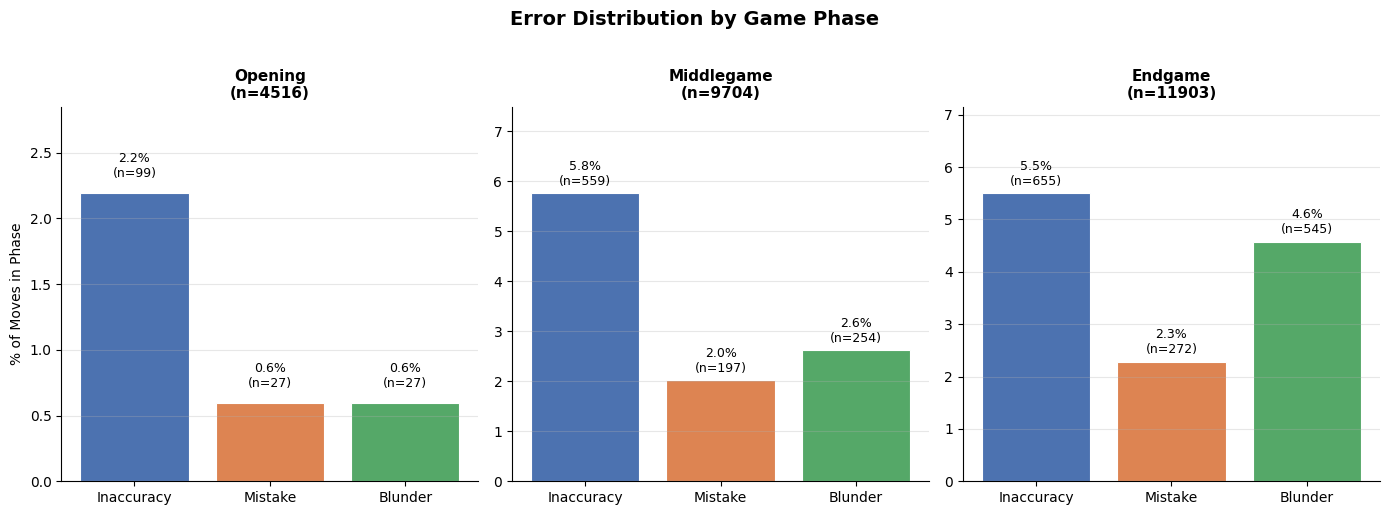

In [33]:
# Plot Error Distribution by Game Phase

error_types = ['is_inaccuracy', 'is_mistake', 'is_blunder']
error_labels = ['Inaccuracy', 'Mistake', 'Blunder']
phases = ['is_opening', 'is_middlegame', 'is_endgame']
phase_labels = ['Opening', 'Middlegame', 'Endgame']
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
fig.suptitle('Error Distribution by Game Phase', fontsize=14, fontweight='bold', y=1.02)

for ax, phase_col, phase_label in zip(axes, phases, phase_labels):
    phase_df = df[df[phase_col] == 1]
    total = len(phase_df)

    counts = [phase_df[e].sum() for e in error_types]
    pcts   = [100 * c / total for c in counts]

    bars = ax.bar(error_labels, pcts, color=colors, edgecolor='white', linewidth=0.8)
    ax.set_title(f'{phase_label}\n(n={total})', fontsize=11, fontweight='bold')
    ax.set_ylabel('% of Moves in Phase' if ax == axes[0] else '')
    ax.set_ylim(0, max(pcts) * 1.3)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

    # Annotate bars with count and percentage
    for bar, count, pct in zip(bars, counts, pcts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                f'{pct:.1f}%\n(n={count})', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

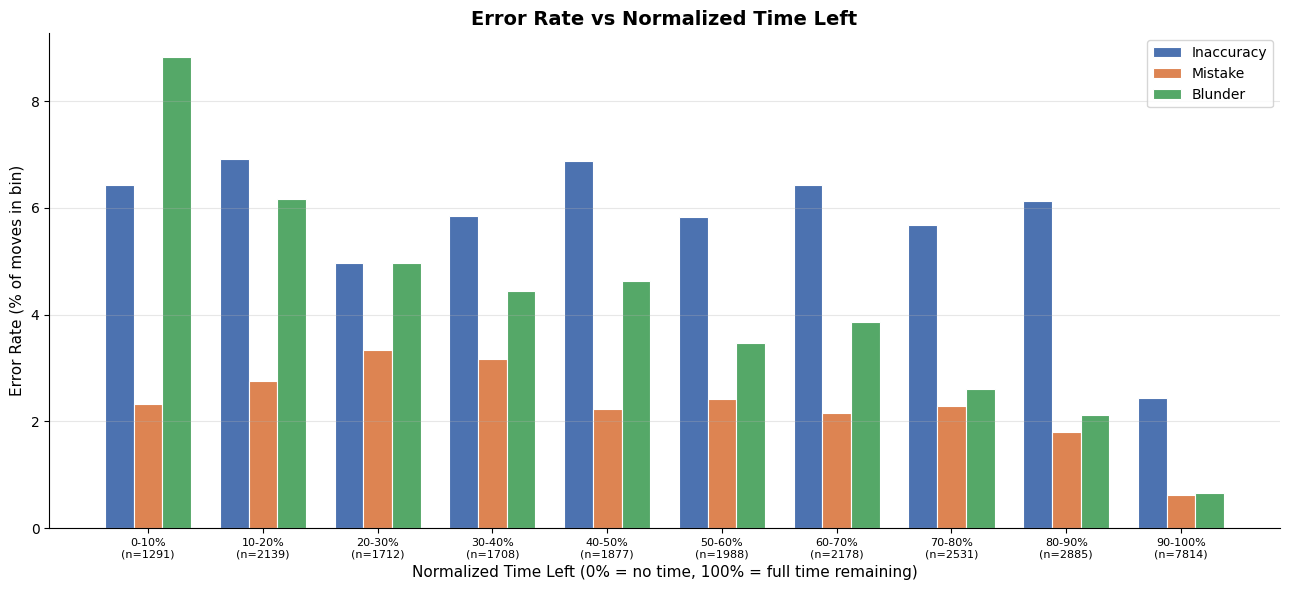

In [34]:
# Plot Error Rate vs Normalized Time Left
df_clean = df

# Clip at 1.0 — any time_left > initial_time (due to large increments) maps to 100%
df_clean['time_left_ratio_clipped'] = df_clean['time_left_ratio'].clip(0, 1)

df_clean['time_left_bin'] = pd.cut(
    df_clean['time_left_ratio_clipped'],
    bins=10,
    labels=[f'{int(i*10)}-{int((i+1)*10)}%' for i in range(10)]
)

# Calculate error rate per bin
grouped    = df_clean.groupby('time_left_bin', observed=True)[error_types].mean() * 100
bin_counts = df_clean.groupby('time_left_bin', observed=True).size()

fig, ax = plt.subplots(figsize=(13, 6))

x     = np.arange(len(grouped))
width = 0.25

for i, (error_col, label, color) in enumerate(zip(error_types, error_labels, colors)):
    ax.bar(x + i * width, grouped[error_col], width,
           label=label, color=color, edgecolor='white', linewidth=0.8)

xtick_labels = [f'{b}\n(n={bin_counts[b]})' for b in grouped.index]
ax.set_xticks(x + width)
ax.set_xticklabels(xtick_labels, fontsize=8)

ax.set_xlabel('Normalized Time Left (0% = no time, 100% = full time remaining)', fontsize=11)
ax.set_ylabel('Error Rate (% of moves in bin)', fontsize=11)
ax.set_title('Error Rate vs Normalized Time Left', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [35]:
# Use this for both modeling and descriptive analytics
df['time_left_ratio_clipped'] = df['time_left_ratio'].clip(0, 1)

# Recalculate time_pressure_norm from the clipped version
df['time_pressure_norm'] = (1 - df['time_left_ratio_clipped']).clip(0, 1)

In [37]:
df.to_csv('data/DoktorAvalanche_with_features_engineered_for_model.csv', index = False)